<h1 align="center"> Introduction to Statistics with Python </h1>




Examples of non-parametric linear regression
===

In [27]:
%reset -f

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
import math as m
import scipy as sp
from statsmodels.stats.anova import anova_lm

In [28]:
# Will fix figure size for this notebook
plt.rcParams["figure.figsize"] = (5,3)

Retrieving data
===


In [29]:
df1 = pd.read_csv('GSRet.csv')
df2 = pd.read_csv('LogVol.csv')
del df1['Unnamed: 0']
del df2['Unnamed: 0']

In [30]:
GSrtn = df1['x']
GSLogVol = df2['x']
len(GSrtn)

3216

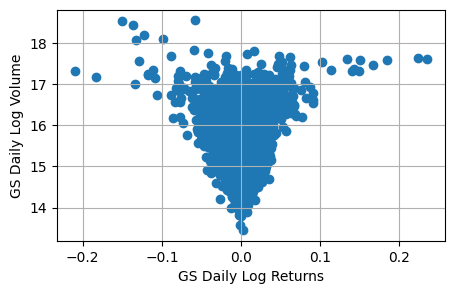

In [31]:
# Can we predict volume from returns?

plt.scatter(x=GSrtn,y=GSLogVol)
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily Log Returns')
plt.grid()
#plt.savefig('GS_vol_rtn')

In [32]:
# Importing stats models and sklearn modules

from statsmodels.stats.anova import anova_lm
from sklearn import linear_model
from statsmodels.sandbox.regression.predstd import wls_prediction_std
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf

 Let's try standard linear regression
====
- Using X = GSrtn as input, without any transformation (except y)

In [33]:
#Linear model - predict log volume from return for Goldman Sachs

X1 = GSrtn
X1 = sm.add_constant(X1) # Need to add a constant to account for intercept
y = GSLogVol

# Initialise model, fit and print results, including conf. interval

model = sm.OLS(y, X1)
lm_1 = model.fit()
y_fitted= lm_1.fittedvalues
print(lm_1.summary())


                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.666
Date:                Wed, 19 Oct 2022   Prob (F-statistic):              0.103
Time:                        11:18:49   Log-Likelihood:                -3631.4
No. Observations:                3216   AIC:                             7267.
Df Residuals:                    3214   BIC:                             7279.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.4009      0.013   1166.569      0.0

In [34]:
print("AIC", lm_1.aic)
print("Coeff")
print(lm_1.params)
print("Coeff Std Err")

AIC 7266.862396194966
Coeff
const    15.400872
x        -0.918811
dtype: float64
Coeff Std Err


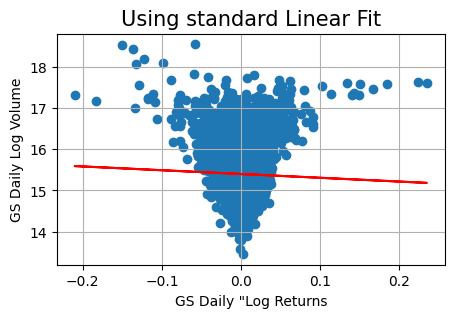

In [35]:
# Plotting again the data, but using lowess to identify a the shape of the relation 
# and showing where the linear regresssion lies

x = GSrtn
plt.plot(x,y_fitted, color = 'r')
plt.scatter(x=GSrtn,y=GSLogVol)
plt.grid()
plt.title("Using standard Linear Fit", fontsize = 15)
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')
plt.show()

Polynomial Regression 
====

In [36]:
x1 = GSrtn
x2 = np.power(x1,2)
x3 = np.power(x1,3)
x4 = np.power(x1,4)
x5 = np.power(x1,5)

df = pd.DataFrame([x1, x2, x3, x4, x5]).T
df.columns=['x1','x2','x3','x4','x5']
df.head(3)


,x1,x2,x3,x4,x5
0,-0.009360,0.000088,-8.200535e-07,7.675787e-09,-7.184618e-11
1,0.001005,0.000001,1.015871e-09,1.021218e-12,1.026592e-15
2,0.023240,0.000540,1.255106e-05,2.916805e-07,6.778510e-09


In [37]:
X = df
Xnew = sm.add_constant(X)
model = sm.OLS(y, Xnew)
lm_2 = model.fit()
y_fitted= lm_2.fittedvalues
print(lm_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     199.4
Date:                Wed, 19 Oct 2022   Prob (F-statistic):          1.67e-185
Time:                        11:18:49   Log-Likelihood:                -3197.9
No. Observations:                3216   AIC:                             6408.
Df Residuals:                    3210   BIC:                             6444.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.2608      0.012   1229.698      0.0

In [38]:
print("AIC", lm_2.aic)
print("Coeff")
print(lm_2.params)
print("Coeff Std Err")

AIC 6407.710278682505
Coeff
const       15.260835
x1           0.457365
x2         320.124665
x3        -346.955580
x4       -6649.988319
x5       11220.931932
dtype: float64
Coeff Std Err


In [39]:
X = df[['x1','x2','x3','x4']]
Xnew = sm.add_constant(X)
Xnew.head()

,const,x1,x2,x3,x4
0,1.0,-0.009360,0.000088,-8.200535e-07,7.675787e-09
1,1.0,0.001005,0.000001,1.015871e-09,1.021218e-12
2,1.0,0.023240,0.000540,1.255106e-05,2.916805e-07
3,1.0,0.001717,0.000003,5.057585e-09,8.681422e-12
4,1.0,0.019555,0.000382,7.477458e-06,1.462195e-07


In [40]:
model = sm.OLS(y, Xnew)
lm_3 = model.fit()
y_fitted= lm_3.fittedvalues
print(lm_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     243.1
Date:                Wed, 19 Oct 2022   Prob (F-statistic):          1.36e-182
Time:                        11:18:49   Log-Likelihood:                -3207.4
No. Observations:                3216   AIC:                             6425.
Df Residuals:                    3211   BIC:                             6455.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.2648      0.012   1229.867      0.0

In [41]:
print("AIC", lm_3.aic)
print("Coeff")
print(lm_3.params)
print("Coeff Std Err")

AIC 6424.831845466775
Coeff
const      15.264815
x1         -1.099209
x2        309.544391
x3        132.545653
x4      -6055.062938
dtype: float64
Coeff Std Err


Try Orthonormal Polynomial
===

In [42]:
# Bespoke function returning a set of orthonormal polynomials 

def polyFit(x, degree = 1):
    n = degree + 1
    x = np.asarray(x).flatten()
    if(degree >= len(np.unique(x))):
            stop("'degree' does not correspond to number of points")
    xbar = np.mean(x)
    x = x - xbar
    X = np.fliplr(np.vander(x, n))
    q,r = np.linalg.qr(X)

    z = np.diag(np.diag(r))
    raw = np.dot(q, z)

    norm2 = np.sum(raw**2, axis=0)
    alpha = (np.sum((raw**2)*np.reshape(x,(-1,1)), axis=0)/norm2 + xbar)[:degree]
    Z = raw / np.sqrt(norm2)
    Z = np.delete(Z, 0, axis=1) #don't need constant, as will add to model
    return Z, norm2, alpha


In [43]:
# Given some set of data, return valuation at orthonormal polynomials

def polyPredict(x, alpha, norm2, degree = 1):
    x = np.asarray(x).flatten()
    n = degree + 1
    Z = np.empty((len(x), n))
    Z[:,0] = 1
    if degree > 0:
        Z[:, 1] = x - alpha[0]
    if degree > 1:
        for i in np.arange(1,degree):
            Z[:, i+1] = (x - alpha[i]) * Z[:, i] - (norm2[i] / norm2[i-1]) * Z[:, i-1]
    Z = Z/ np.sqrt(norm2)
    Z = np.delete(Z, 0, axis=1) #don't need constant, as will add to model
    return Z

In [44]:
# Understanding the functions

x = np.arange(1,101,1)

Z, norm2, alpha = polyFit(x,degree = 3);
p1 = Z[0:100,0]
p2 = Z[0:100,1]
p3 = Z[0:100,2]

In [45]:
# How do we check they are orthogonal? Their inner product is zero:

print(sum(p1*p2))
print(sum(p2*p3))
print(sum(p1*p3))

-1.249000902703301e-16
-1.3183898417423734e-16
-1.5959455978986625e-16


In [46]:
# And we can check that they are in fact orthonormal as 

print(sum(p1*p1))
print(sum(p2*p2))
print(sum(p3*p3))

1.0
1.0000000000000004
0.9999999999999999


Regression with polynomials up to degree 2
====

In [47]:
# Now let's use my_poly_fit to fit polyomials to our GSrtn

X1 = GSrtn
XPoly2_GSrtn, norm2_GSrtn, alpha_GSrtn = polyFit(X1,degree = 2)
y = GSLogVol


In [48]:
# Initialise model, fit and print results, including conf. interval

XPoly2_GSrtn = sm.add_constant(XPoly2_GSrtn)
model = sm.OLS(y, XPoly2_GSrtn)
lm_4 = model.fit()
print(lm_4.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     255.6
Date:                Wed, 19 Oct 2022   Prob (F-statistic):          9.55e-104
Time:                        11:18:49   Log-Likelihood:                -3395.3
No. Observations:                3216   AIC:                             6797.
Df Residuals:                    3213   BIC:                             6815.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.4009      0.012   1255.238      0.0

In [49]:
print("AIC", lm_4.aic)
print("Coeff")
print(lm_4.params)
print("Coeff Std Err")

AIC 6796.661138457353
Coeff
const    15.400866
x1       -1.222336
x2       15.684647
dtype: float64
Coeff Std Err


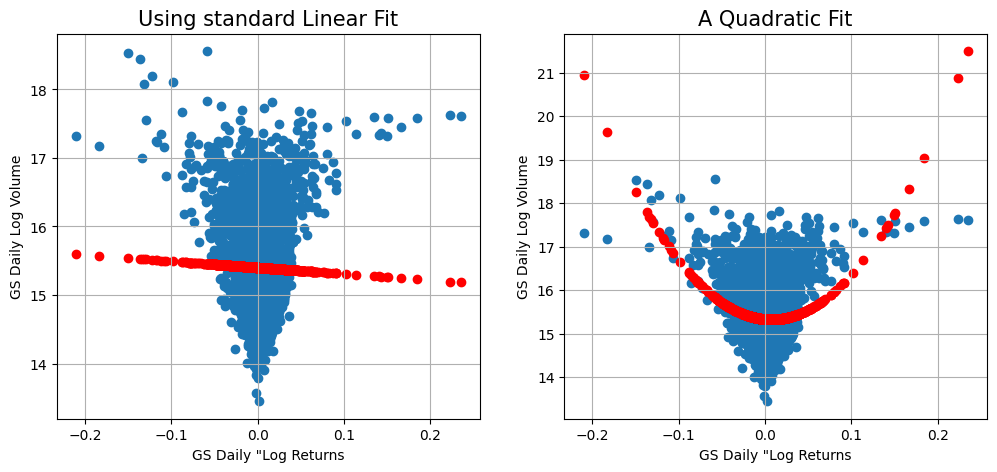

In [50]:
X1 = GSrtn
X1 = sm.add_constant(X1)
y = GSLogVol
model = sm.OLS(y, X1)
lm_1 = model.fit()
y_fitted= lm_1.fittedvalues


plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
x = GSrtn
plt.scatter(x=GSrtn,y=GSLogVol)
plt.scatter(x,y_fitted, color = 'r')
plt.grid()
plt.title("Using standard Linear Fit",fontsize = 15)
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')

X1 = GSrtn
XPoly2_GSrtn, norm2_GSrtn, alpha_GSrtn = polyFit(X1,degree = 2)
y = GSLogVol
XPoly2_GSrtn = sm.add_constant(XPoly2_GSrtn)

model = sm.OLS(y, XPoly2_GSrtn)
lm_2 = model.fit()
model_fitted_y = lm_2.fittedvalues

plt.subplot(1,2, 2)

plt.scatter(x=X1,y=y)
plt.grid()
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')
plt.title('A Quadratic Fit', fontsize = 15)
plt.scatter(X1,model_fitted_y, color = 'red')
#plt.savefig("GS_compare_OLS_Quadr")


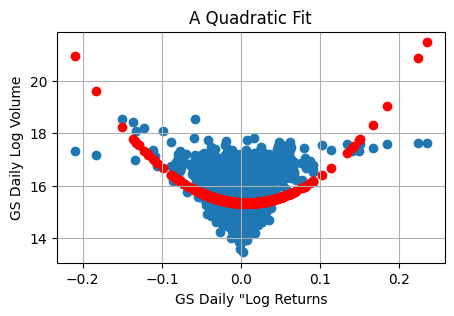

In [51]:
model_fitted_y = lm_4.fittedvalues
plt.scatter(x=X1,y=y)
plt.grid()
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')
plt.title('A Quadratic Fit')
plt.scatter(X1,model_fitted_y, color = 'red')
plt.show()

TypeError: regplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 3 keyword-only arguments) were given

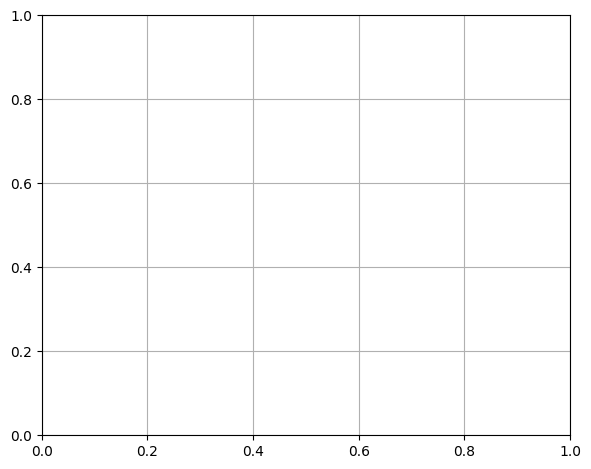

In [52]:
# Now check residuals

plt.figure(1, figsize=(15,12))
plt.subplot(2,2, 1)
plt.grid()
plt_result = sns.regplot(model_fitted_y, lm_4.resid, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Residuals vs Fitted')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Residuals')


plt.subplot(2,2, 2) # 2 by 2 and plot 2
plt.figure(1, figsize=(15,12))
sqrt_stdRes = np.sqrt(np.abs(lm_4.resid_pearson))
plt.grid()
plt_result = sns.regplot(model_fitted_y, sqrt_stdRes, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Scale-Location')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Sqrt Std Residuals')

plt.show()


Regression with polynomials up to degree 10
====

In [ ]:
# Using my_poly_fit, fit polyomials of up to degree 10!

X1 = GSrtn
XPoly10_GSrtn, norm2_GSrtn_10, alpha_GSrtn_10 = polyFit(X1,degree = 10)
y = GSLogVol

In [ ]:
# Are the polynomials generated still orthonormal - many combinations to check, let me just see a few...

p7 = XPoly10_GSrtn[0:5032,7]
p5 = XPoly10_GSrtn[0:5032,5]

print(sum(p5*p7))
print(sum(p5*p5))
print(sum(p7*p7))

In [ ]:
# Initialise model, fit and print results

XPoly10_GSrtn = sm.add_constant(XPoly10_GSrtn)
model = sm.OLS(y, XPoly10_GSrtn)
lm_10 = model.fit()
print(lm_10.summary())


In [ ]:
XPoly10_GSrtn[0]


In [ ]:
print("AIC", lm_10.aic)
print("Coeff")
print(lm_10.params)
print("Coeff Std Err")

In [ ]:
# Using the model to predict given new data:

newX1 = np.linspace(X1.min(), X1.max(), 300)
predict_XPoly10 = polyPredict(newX1, alpha_GSrtn_10, norm2_GSrtn_10, degree = 10) 
ones = np.ones(len(newX1),dtype=np.int16)
predict_XPoly10 = np.insert(predict_XPoly10, 0, ones, axis = 1)
y_predict_10 = lm_10.predict(predict_XPoly10)

In [ ]:
# Check predicted values of new points to see the curve 

plt.scatter(x=X1,y=y)
plt.plot(newX1, y_predict_10, 'C4', lw=3)
plt.scatter(X1,lm_10.fittedvalues, color = 'red')
plt.ylabel('Log Volume')
plt.xlabel('Returns')
plt.grid()
plt.show()


In [ ]:
# Now check residuals

plt.figure(1, figsize=(15,12))
plt.subplot(2,2, 1)
plt.grid()
plt_result = sns.regplot(model_fitted_y, lm_10.resid, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Residuals vs Fitted')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Residuals')


plt.subplot(2,2, 2) # 2 by 2 and plot 2
plt.figure(1, figsize=(15,12))
sqrt_stdRes = np.sqrt(np.abs(lm_10.resid_pearson))
plt.grid()
plt_result = sns.regplot(model_fitted_y, sqrt_stdRes, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Scale-Location')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Sqrt Std Residuals')

plt.show()

In [ ]:
# Check residuals: QQ plot

fig = sm.qqplot(lm_10.resid_pearson, line='45')
plt.title('Normal QQ plot', fontsize=15)
plt.grid()
plt.show()

Regression with polynomials up to degree 20!
====

In [ ]:
# Using my_poly_fit, fit polyomials of up to degree 10!

X1 = GSrtn
XPoly20_GSrtn, norm2_GSrtn_20, alpha_GSrtn_20 = polyFit(X1,degree = 20)
y = GSLogVol

# Initialise model, fit and print results

XPoly20_GSrtn = sm.add_constant(XPoly20_GSrtn)
model = sm.OLS(y, XPoly20_GSrtn)
lm_20 = model.fit()
y_fitted_20 = lm_20.fittedvalues
print(lm_20.summary())

In [ ]:
print("AIC", lm_20.aic)
print("Coeff")
print(lm_20.params)
print("Coeff Std Err")

In [ ]:
print("AIC 20", lm_20.aic)
print("AIC 10", lm_10.aic)
print("BIC 20", lm_20.bic)
print("BIC 10", lm_10.bic)

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
newX1 = np.linspace(X1.min(), X1.max(), 300)
predict_XPoly10 = polyPredict(newX1, alpha_GSrtn_10, norm2_GSrtn_10, degree = 10) 
ones = np.ones(len(newX1),dtype=np.int16)
predict_XPoly10 = np.insert(predict_XPoly10, 0, ones, axis = 1)
y_predict_10 = lm_10.predict(predict_XPoly10)

plt.scatter(x=X1,y=y)
plt.plot(newX1, y_predict_10, 'C4', lw=3)
plt.scatter(X1,lm_10.fittedvalues, color = 'red')
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')
plt.title('An Orthonormal 10th degree Polynomial Fit', fontsize = 15)
plt.ylim((12,20))
plt.grid()


plt.subplot(1,2, 2)
newX1 = np.linspace(X1.min(), X1.max(), 3612)
predict_XPoly20= polyPredict(newX1, alpha_GSrtn_20, norm2_GSrtn_20, degree = 20) 
ones = np.ones(len(newX1),dtype=np.float)
predict_XPoly20 = np.insert(predict_XPoly20, 0, ones, axis = 1)
y_predict_20 = lm_20.predict(predict_XPoly20)

plt.scatter(x=X1,y=y)
plt.scatter(x= newX1,y= y_predict_20, color = 'g')
plt.scatter(X1,y_fitted_20, color = 'red')
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')
plt.title('A 20th degree Polynomial Fit', fontsize = 15)
plt.ylim((12,20))
plt.grid()
#plt.savefig("GS_10_20")


In [ ]:
# Now check residuals

plt.figure(1, figsize=(15,12))
plt.subplot(2,2, 1)
plt.grid()
plt_result = sns.regplot(y_fitted_20, lm_20.resid, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Residuals vs Fitted')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Residuals')


plt.subplot(2,2, 2) # 2 by 2 and plot 2
plt.figure(1, figsize=(15,12))
sqrt_stdRes = np.sqrt(np.abs(lm_20.resid_pearson))
plt.grid()
plt_result = sns.regplot(y_fitted_20, sqrt_stdRes, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Scale-Location')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Sqrt Std Residuals')

plt.show()

In [ ]:
# Check residuals: QQ plot

fig = sm.qqplot(lm_20.resid_pearson, line='45')
plt.title('Normal QQ plot', fontsize=15)
plt.grid()
plt.show()


Regression Fitting a Piecewise Linear Model
====

In [ ]:
# Define a piecewise linear function given data and knots

def pielinear(x, knots):
    n = len(knots) 
    res = x 
    nullArray = np.zeros(len(x))
    for i in np.arange(0,n):
        res = np.vstack((res,np.maximum(x-knots[i],nullArray)))
    return res

In [ ]:
# Test my function:

x = np.asarray([1,2,3,4,5,6,7,8])
knots = np.asarray([1.2,1.8])
pielinear(x,knots).T

In [ ]:
# Choose knots to be quantiles - notice, there are a large number of choices for these points...

x = GSrtn.values
df = 6 # degrees of freedom
n = df - 1 
percentiles = np.asarray([1/n*100,2/n*100,3/n*100,4/n*100])
knots_6 = np.percentile(x, percentiles)
X_piece = pielinear(x,knots_6)
x1 = X_piece[0].T
x2 = X_piece[1].T
x3 = X_piece[2].T
x4 = X_piece[3].T
x5 = X_piece[4].T
print(knots_6)

In [ ]:
# Create a dataframe with all relevant data

y = GSLogVol
df = pd.DataFrame([y,x1, x2, x3, x4, x5]).T#Transpose
df.columns=['y','x1','x2','x3','x4','x5']
df.head()

In [ ]:
# Piecewise linear regression

model = smf.ols(formula = 'y ~ x1 + x2 + x3 + x4 + x5', data = df)
lm_pwl = model.fit()
lm_pwl.summary()

In [ ]:
print("AIC lm_pwl", lm_pwl.aic)


In [ ]:
y_fitted_pwl = lm_pwl.fittedvalues
x = GSrtn
plt.scatter(x=GSrtn,y=GSLogVol)
plt.scatter(x,y_fitted_pwl, color = 'red')
plt.ylabel('Log Volume')
plt.xlabel('Returns')
plt.grid()
plt.show()

- Can we try without the formula?

In [ ]:
# Initialise model, fit and print results

X_piece_T = X_piece.T
model = sm.OLS(y, X_piece_T)
lm_piecewise = model.fit()
print(lm_piecewise.summary());


Wait!
====

- Did something go wrong? 

- Why are the coefficients no longer the same?

In [ ]:
# Initialise model, fit and print results

X_piece_T = X_piece.T
X_piece_T = sm.add_constant(X_piece_T)
model = sm.OLS(y, X_piece_T)
lm_piecewise_6 = model.fit()
y_fitted_piecewise_6 = lm_piecewise_6.fittedvalues
print(lm_piecewise_6.summary())
X_piece_T.shape


In [ ]:
lm_pwl

In [ ]:
# Now check residuals

plt.figure(1, figsize=(15,12))
plt.subplot(2,2, 1)
plt.grid()
plt_result = sns.regplot(y_fitted_piecewise_6, lm_piecewise_6.resid, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Residuals vs Fitted')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Residuals')


plt.subplot(2,2, 2) # 2 by 2 and plot 2
plt.figure(1, figsize=(15,12))
sqrt_stdRes = np.sqrt(np.abs(lm_piecewise_6.resid_pearson))
plt.grid()
plt_result = sns.regplot(y_fitted_piecewise_6, sqrt_stdRes, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Scale-Location')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Sqrt Std Residuals')

plt.show()

In [ ]:
# Check residuals: QQ plot

fig = sm.qqplot(lm_20.resid_pearson, line='45')
plt.title('Normal QQ plot', fontsize=15)
plt.grid()
plt.show()

Plotting prediction intervals
====

In [ ]:
# Predict given new X's

newX1 = np.linspace(X1.min(), X1.max(), 3612)
X_piece_new = pielinear(newX1,knots_6)
X_piece_new_T = X_piece_new.T
ones = np.ones(len(newX1),dtype=np.float)
X_piece_new_T = np.insert(X_piece_new_T, 0, ones, axis = 1)

In [ ]:
#Prediction interval

model_pred_y = lm_piecewise_6.predict(X_piece_new_T)
res = lm_piecewise_6.resid
model_pred_y_up = model_pred_y + 1.96*np.std(res)
model_pred_y_down = model_pred_y - 1.96*np.std(res)
model_fitted_y = lm_piecewise.fittedvalues

plt.scatter(x=GSrtn,y=GSLogVol)
plt.scatter(x=GSrtn, y=y_fitted_piecewise_6, color = 'red')
plt.plot(newX1,model_pred_y_up, color = 'blue')
plt.plot(newX1,model_pred_y_down, color = 'blue')
plt.ylabel('Log Volume')
plt.xlabel('Returns')
plt.grid()

plt.show()


Regression using splines
====

In [ ]:
percentiles = np.asarray([10,20,40,50,60,70,80,90])
knots = np.percentile(x, percentiles)
print(knots)

In [ ]:
# Raw cubic basis function given data and knots

def cubic(x, knots):
    n = len(knots) 
    res = x
    res = np.vstack((res,x**2))
    res = np.vstack((res,x**3))
    nullArray = np.zeros(len(x))
    for i in np.arange(0,n):
        res = np.vstack((res,np.maximum(x-knots[i],nullArray)**3))
    return res

In [ ]:
test = cubic(x,knots).T
test.shape

In [ ]:
x = GSrtn
X_cubic = cubic(x,knots).T
X_cubic.shape

In [ ]:
X_cubic = sm.add_constant(X_cubic)
model = sm.OLS(y, X_cubic)
lm_cubic = model.fit()
print(lm_cubic.summary())

In [ ]:
y_fitted_cubic = lm_cubic.fittedvalues
x = GSrtn
plt.grid()
plt.scatter(x=GSrtn,y=GSLogVol)
plt.ylabel('GS Daily Log Volume')
plt.xlabel('GS Daily "Log Returns')
plt.title('A Cupbic Spline Piecewise Fit - AIC 5987, BIC = 6060, 8 knots', fontsize = 15)
plt.scatter(x,y_fitted_cubic, color = 'red')
plt.savefig("GS_Cubic_spline")

In [ ]:
print("AIC 20", lm_20.aic)
print("AIC 10", lm_10.aic)
print("AIC raw cubic spline 8 knots", lm_cubic.aic)
print("")
print("BIC 20", lm_20.bic)
print("BIC 10", lm_10.bic)
print("BIC raw cubic spline 8 knots", lm_cubic.bic)


An example with B-Splines
====

In [ ]:
# Finding the bSpline matrix in Python equivalent to R
import patsy
from patsy import dmatrix

In [ ]:
x = GSrtn
y = GSLogVol
data = {"x": x}
x_matrix = dmatrix("bs(x, df=7)", data)
x_transformed = np.asarray(x_matrix)
x_transformed = np.delete(x_transformed, 0, axis=1) #remove intercept

x_transformed = sm.add_constant(x_transformed)
model = sm.OLS(y, x_transformed)
lm_bspline = model.fit()
print(lm_bspline.summary())


In [ ]:
y_fitted_bSpline = lm_bspline.fittedvalues
x = GSrtn
plt.grid()
plt.scatter(x=x,y=GSLogVol)
plt.ylabel('Log Volume')
plt.xlabel('Returns')
plt.scatter(x,y_fitted_bSpline, color = 'red')
plt.show()

In [ ]:
print("AIC 20", lm_20.aic)
print("AIC 10", lm_10.aic)
print("AIC raw cubic spline 8 knots", lm_cubic.aic)
print("AIC bSpline 6 knots", lm_bspline.aic)
print("")
print("BIC 20", lm_20.bic)
print("BIC 10", lm_10.bic)
print("BIC raw cubic spline 8 knots", lm_cubic.bic)
print("BIC bSpline 6 knots", lm_bspline.bic)

In [ ]:
# Now check residuals

plt.figure(1, figsize=(15,12))
plt.subplot(2,2, 1)
plt.grid()
plt_result = sns.regplot(y_fitted_bSpline, lm_bspline.resid, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Residuals vs Fitted')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Residuals')


plt.subplot(2,2, 2) # 2 by 2 and plot 2
plt.figure(1, figsize=(15,12))
sqrt_stdRes = np.sqrt(np.abs(lm_bspline.resid_pearson))
plt.grid()
plt_result = sns.regplot(y_fitted_bSpline, sqrt_stdRes, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3, 'alpha': 0.8})
plt_result.set_title('Scale-Location')
plt_result.set_xlabel('Fitted values')
plt_result.set_ylabel('Sqrt Std Residuals')

plt.show()

In [ ]:
# Check residuals: QQ plot

fig = sm.qqplot(lm_bspline.resid_pearson, line='45')
plt.title('Normal QQ plot', fontsize=15)
plt.grid()
plt.show()

An example with Natural-Cubic-Splines
====

In [ ]:
x = np.linspace(0., 1., 100)
y = dmatrix("cr(x,knots=[0.25,0.5,0.75],)-1", {"x": x})#constraints='center'
b = np.array([1.3, 0.6, 0.9, 0.4, 1.6])
y=np.asarray(y)
ns_p = pd.DataFrame(y) 
print(y.shape)
plt.plot(x, y*b);
plt.plot(x, np.dot(y, b), color='k', linewidth=3);

In [ ]:
# Specifying 3 internal knots = 5 total knots, hence total 
# df = 3 (size of powers in spline) + 5 (knots splines) + 1 (intercept) = 9
# but since it is a natural cubic spline, there are 2 more constraints on each boundary
# hence df = 9-4 = 5 (ish as intercept not counted)

In [ ]:
y_fitted_cubic = lm_cubic.fittedvalues
x = GSrtn
plt.grid()
plt.scatter(x=x,y=GSLogVol)
plt.ylabel('Log Volume')
plt.xlabel('Returns')
plt.scatter(x,y_fitted_cubic, color = 'red')
plt.show()

In [ ]:
# Data
x = GSrtn
y = GSLogVol

# Use Natural Spline Regression
data = {"x": x}
x_ns = dmatrix("cr(x, df=7)", data)
x_ns = np.asarray(x_ns)
x_ns = sm.add_constant(x_ns)

model = sm.OLS(y, x_ns)
lm_spline = model.fit()
print(lm_spline.summary())

In [ ]:
print("AIC 20", lm_20.aic)
print("AIC 10", lm_10.aic)
print("AIC raw cubic spline 8 knots", lm_cubic.aic)
print("AIC bSpline 6 knots", lm_bspline.aic)
print("AIC natural cubic spline 6 knots", lm_spline.aic)
print("")
print("BIC 20", lm_20.bic)
print("BIC 10", lm_10.bic)
print("BIC raw cubic spline 8 knots", lm_cubic.bic)
print("BIC bSpline 6 knots", lm_bspline.bic)
print("BIC natural cubic 6 knots", lm_spline.bic)